# False-positive **types** vs noise type — Epsilon_study_2

Every *false* segment is classified by its topology in the compatibility graph
$C = sI - A$ (off-diagonal couplings), following
`Run3_Verification` (`cluster_classes`):

| type | meaning | clean Run-3 behaviour |
|------|---------|-----------------------|
| **isolated** | no coupling (component size 1) — sits at the Hopfield attractor $\delta/(\delta+\gamma)=0.25<\tau$ | 99.7 % of all false; **never** a false positive |
| **pair** | 2-node component | rare; inactive |
| **chain≥3** | path of ≥3 (max degree < 3) | active → false positive |
| **hub** | component with a node of degree ≥3 (star centre) | active → false positive |

In clean events the false positives come **only** from coupled (chain/hub) clusters.
This notebook asks how that picture changes with **detector noise type**
($\sigma_{\rm res}$ vs $\sigma_{\rm scatt}$): does noise (a) grow the coupled
populations, and (b) break the solver so even *isolated* segments activate?

Data: `outputs/false_positive_types/fp_census.csv` (built by `build_fp_census.py`,
which regenerates each stored event from its seed — reproduction verified identical
to the stored truth mask).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
HERE = Path('.').resolve()
FIG = HERE/'figures'/'false_positive_types'; FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi':110, 'font.size':11})

df = pd.read_csv(HERE/'outputs'/'false_positive_types'/'fp_census.csv')
df = df[df['repro_ok'] == True].copy()
FALSE_TYPES = ['isolated','pair','chain>=3','hub']
COL = {'isolated':'#999999','pair':'#7fb0d0','chain>=3':'#d6604d','hub':'#7a0177'}
SR = sorted(df['sigma_res'].unique()); SS = sorted(df['sigma_scatt'].unique())
print('cells:', df.groupby(['sigma_res','sigma_scatt']).ngroups,
      '| T:', sorted(df['n_trk'].unique()),
      '| sigma_res:', SR, '| sigma_scatt:', SS)

# mean over reps -> one row per (sigma_res, sigma_scatt, n_trk, type)
# act_Q_wp = 1BQF activation at its per-solve wp99 HEADLINE working point
# (efficiency-first; wp99 log 2026-06-14); act_Q = fixed-tau=0.35 record.
agg = (df.groupby(['sigma_res','sigma_scatt','n_trk','type'], as_index=False)
         [['count','act_C','act_Q','act_Q_wp']].mean())

print('loaded', len(df), 'rows')

cells: 12 | T: [np.int64(50), np.int64(100), np.int64(200), np.int64(400)] | sigma_res: [np.float64(0.0), np.float64(0.01), np.float64(0.02), np.float64(0.05)] | sigma_scatt: [np.float64(0.0001), np.float64(0.0003), np.float64(0.0005)]
loaded 1495 rows


## 1 · False-segment topology census vs noise (T = 200)

How the *population* of false segments splits across the four topology classes as
detector noise increases. Wider noise → wider $\varepsilon$ → more false pairs pass
the angle cut → the isolated majority gives way to coupled pairs / chains / hubs.

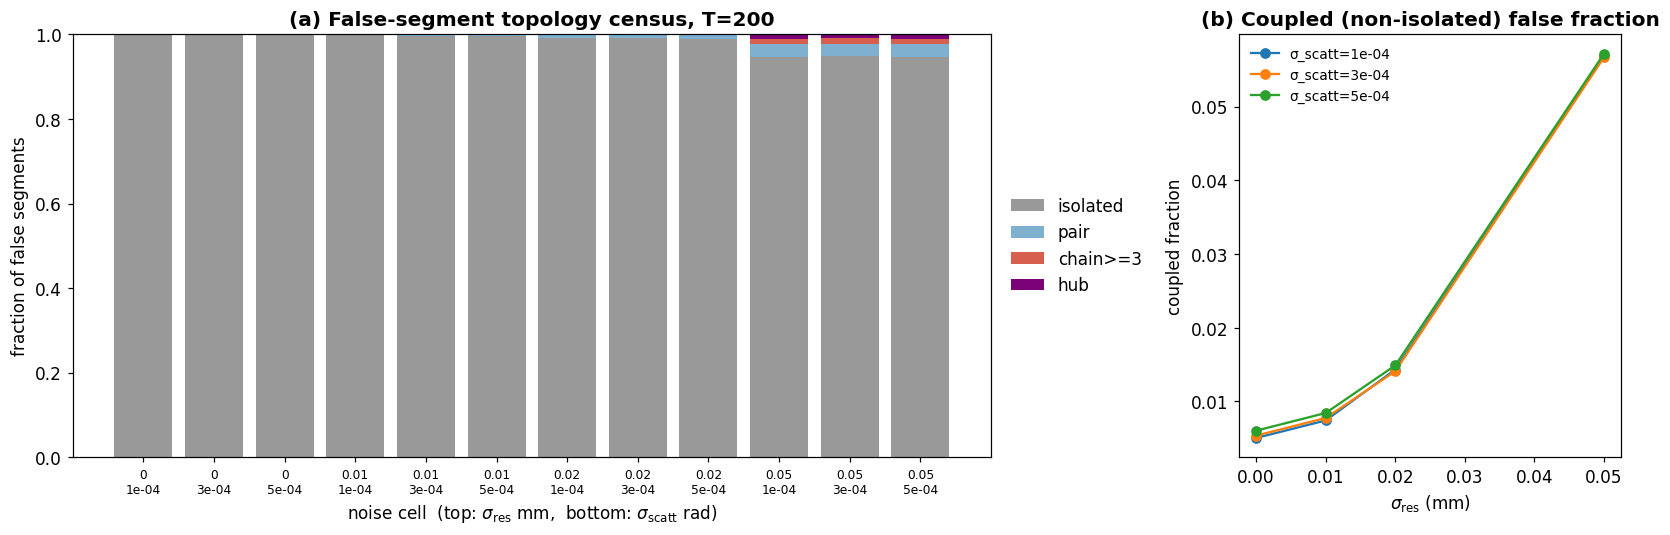

coupled fraction rises with sigma_res; sigma_scatt has a weaker effect


In [2]:
T = 200
sub = agg[agg['n_trk']==T]
cells = [(sr,ss) for sr in SR for ss in SS]
labels = [f"{sr:g}\n{ss:.0e}" for sr,ss in cells]

frac = np.zeros((len(cells), len(FALSE_TYPES)))
for i,(sr,ss) in enumerate(cells):
    s = sub[(sub['sigma_res']==sr)&(sub['sigma_scatt']==ss)]
    cnt = {t: float(s[s['type']==t]['count'].sum()) for t in FALSE_TYPES}
    tot = sum(cnt.values()) or 1.0
    frac[i] = [cnt[t]/tot for t in FALSE_TYPES]

fig, ax = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios':[2.4,1]})
bottom = np.zeros(len(cells))
x = np.arange(len(cells))
for j,t in enumerate(FALSE_TYPES):
    ax[0].bar(x, frac[:,j], bottom=bottom, color=COL[t], label=t, width=0.82)
    bottom += frac[:,j]
ax[0].set_xticks(x); ax[0].set_xticklabels(labels, fontsize=8)
ax[0].set_ylabel('fraction of false segments'); ax[0].set_ylim(0,1)
ax[0].set_xlabel(r'noise cell  (top: $\sigma_{\rm res}$ mm,  bottom: $\sigma_{\rm scatt}$ rad)')
ax[0].set_title(f'(a) False-segment topology census, T={T}', fontweight='bold')
ax[0].legend(loc='center left', bbox_to_anchor=(1.005,0.5), frameon=False)

# (b) coupled (non-isolated) fraction vs sigma_res, lines per sigma_scatt
ax[1].set_title('(b) Coupled (non-isolated) false fraction', fontweight='bold')
for k,ss in enumerate(SS):
    y = []
    for sr in SR:
        s = sub[(sub['sigma_res']==sr)&(sub['sigma_scatt']==ss)]
        tot = float(s['count'].sum()) or 1.0
        iso = float(s[s['type']=='isolated']['count'].sum())
        y.append(1 - iso/tot)
    ax[1].plot(SR, y, 'o-', label=f'σ_scatt={ss:.0e}')
ax[1].set_xlabel(r'$\sigma_{\rm res}$ (mm)'); ax[1].set_ylabel('coupled fraction')
ax[1].legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(FIG/'census_vs_noise_T200.png', bbox_inches='tight', facecolor='white')
fig.savefig(FIG/'census_vs_noise_T200.pdf', bbox_inches='tight'); plt.show()
print('coupled fraction rises with sigma_res; sigma_scatt has a weaker effect')

## 2 · Which types become false positives — per-type activation heatmaps (T = 200)

For each topology class, the **activation rate** = fraction of that class with
solver score above the solver's **operating-point** $\tau$ (i.e. how often it becomes
a *false positive*), over the $\sigma_{\rm res}\times\sigma_{\rm scatt}$ grid:
**classical at the fixed $\tau=0.35$; the 1BQF at its per-solve wp99
efficiency-first $\tau$** (the headline convention — judging the 1BQF at 0.35 is
the ~75 %-efficiency cut artefact).

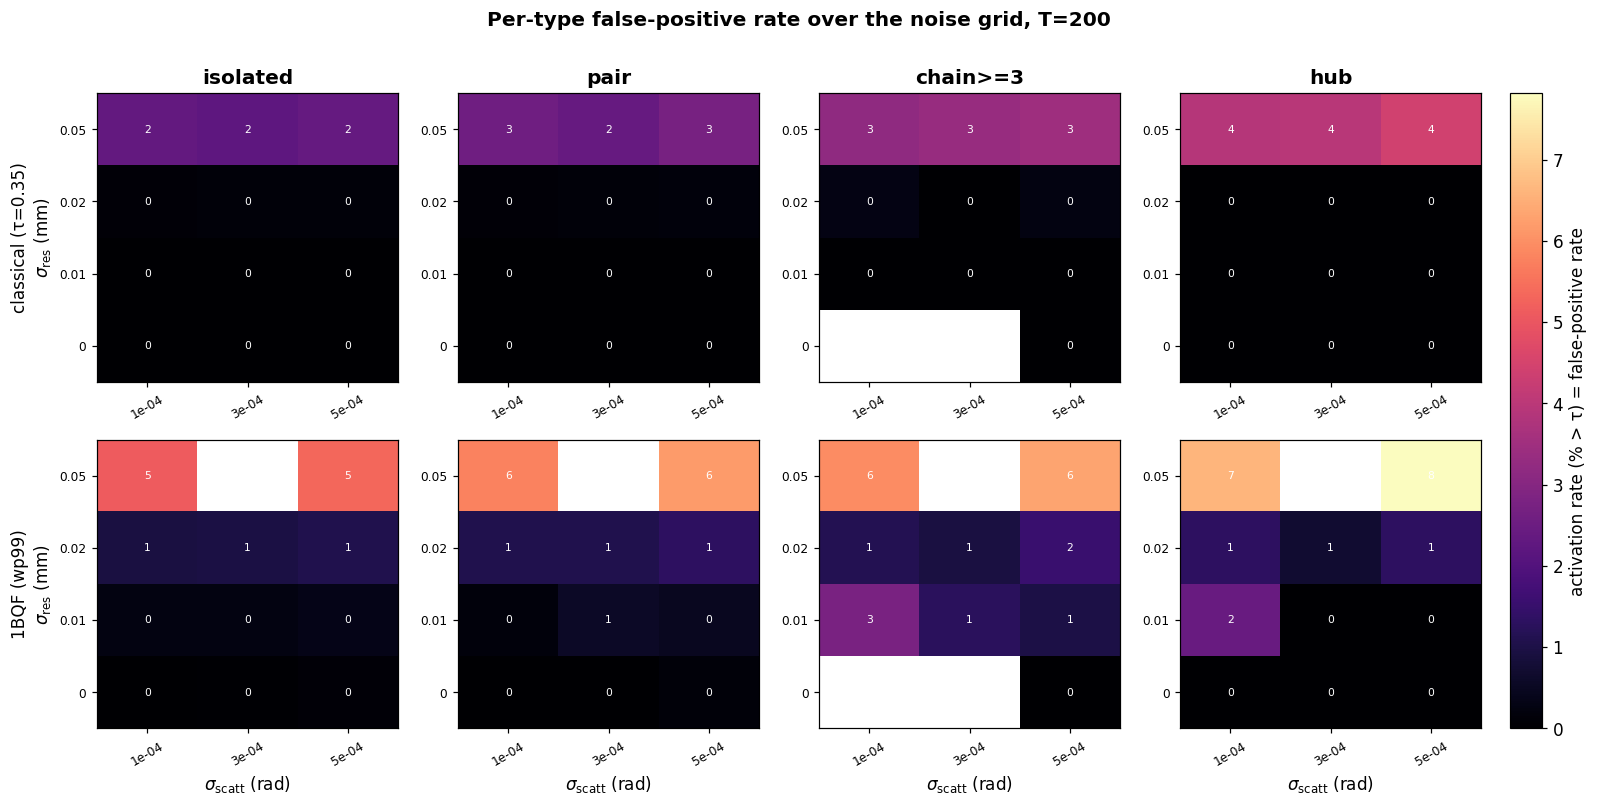

In [3]:
T = 200
sub = agg[agg['n_trk']==T]
def grid_rate(solver):
    out = {}
    for t in FALSE_TYPES:
        g = np.full((len(SR), len(SS)), np.nan)
        for a,sr in enumerate(SR):
            for b,ss in enumerate(SS):
                s = sub[(sub['sigma_res']==sr)&(sub['sigma_scatt']==ss)&(sub['type']==t)]
                if len(s):
                    c = float(s['count'].iloc[0]); act = float(s[solver].iloc[0])
                    g[a,b] = 100*act/c if c>0 else np.nan
        out[t] = g
    return out
rates = {'classical (τ=0.35)':grid_rate('act_C'), '1BQF (wp99)':grid_rate('act_Q_wp')}

fig, axes = plt.subplots(2, 4, figsize=(17, 7.5))
vmax = np.nanmax([np.nanmax(rates[s][t]) for s in rates for t in FALSE_TYPES])
for r,solver in enumerate(rates):
    for c,t in enumerate(FALSE_TYPES):
        ax = axes[r,c]; G = rates[solver][t]
        im = ax.imshow(G, origin='lower', aspect='auto', cmap='magma', vmin=0, vmax=vmax)
        ax.set_xticks(range(len(SS))); ax.set_xticklabels([f'{s:.0e}' for s in SS], fontsize=8, rotation=30)
        ax.set_yticks(range(len(SR))); ax.set_yticklabels([f'{s:g}' for s in SR], fontsize=8)
        for a in range(len(SR)):
            for b in range(len(SS)):
                if np.isfinite(G[a,b]): ax.text(b,a,f'{G[a,b]:.0f}',ha='center',va='center',fontsize=7,color='w')
        if r==0: ax.set_title(t, fontweight='bold')
        if c==0: ax.set_ylabel(f'{solver}\n'+r'$\sigma_{\rm res}$ (mm)')
        if r==1: ax.set_xlabel(r'$\sigma_{\rm scatt}$ (rad)')
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label='activation rate (% > τ) = false-positive rate')
fig.suptitle(f'Per-type false-positive rate over the noise grid, T={T}', fontweight='bold', y=0.98)
fig.savefig(FIG/'activation_by_type_grid_T200.png', bbox_inches='tight', facecolor='white')
fig.savefig(FIG/'activation_by_type_grid_T200.pdf', bbox_inches='tight'); plt.show()

## 3 · Composition of the false positives — the isolated-leakage signature

In *clean* Run-3 events false positives are 100 % **coupled** (hub + chain): only
genuinely-confusable triplets fire. The diagnostic question is whether noise makes the
solver instead fire **isolated** segments — uncoupled ones that sit at the
$0.25$ attractor and can only cross $\tau$ if the solution is corrupted.

The data answer (next two cells): once $\sigma_{\rm res}\gtrsim0.02$ mm **both** solvers'
false positives become 94–99 % isolated — the dominant error is no longer coupled-cluster
confusion but a *flood of uncoupled leakage*. And the 1BQF is **not** more resistant:
at low/moderate noise it produces **more** false positives than the classical solver
(e.g. at $\sigma_{\rm res}=0$: 7 vs 183), almost all isolated. That is the quantum
purity problem made concrete.

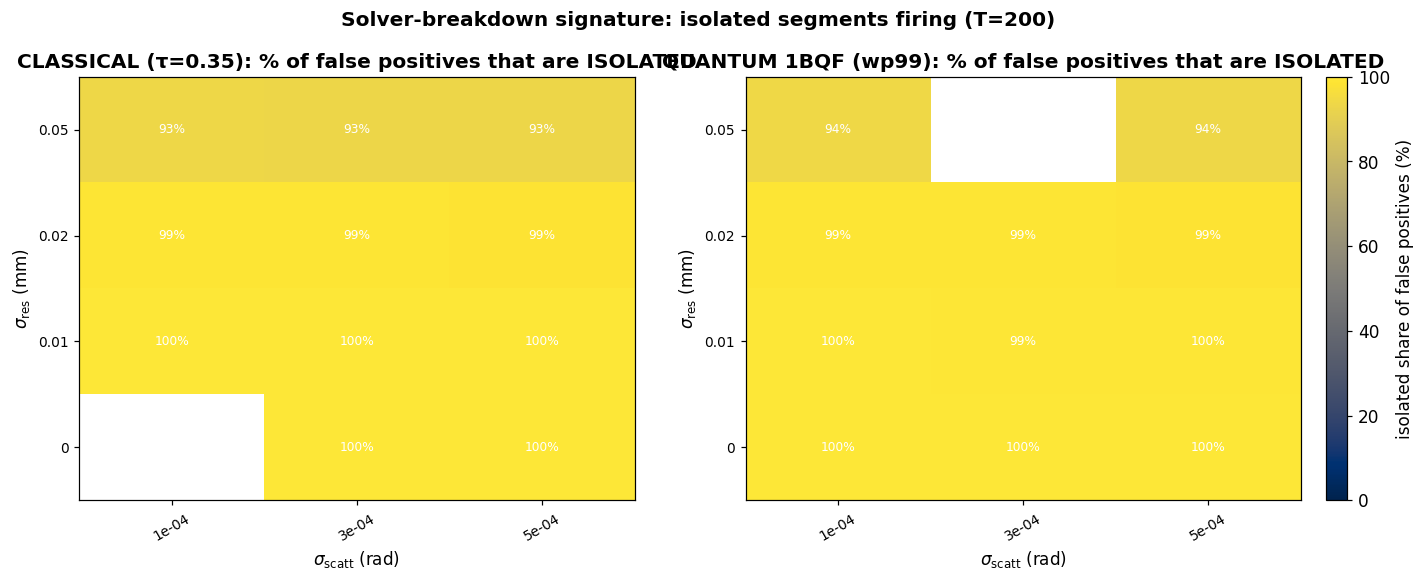

Higher value = more solver corruption (firing uncoupled segments).


In [4]:
T = 200
sub = agg[agg['n_trk']==T]
def fp_comp(solver):
    iso_frac, cells_lbl = [], []
    for sr in SR:
        for ss in SS:
            s = sub[(sub['sigma_res']==sr)&(sub['sigma_scatt']==ss)]
            act = {t: float(s[s['type']==t][solver].sum()) for t in FALSE_TYPES}
            tot = sum(act.values()) or np.nan
            iso_frac.append(100*act['isolated']/tot if tot==tot else np.nan)
            cells_lbl.append((sr,ss))
    return np.array(iso_frac), cells_lbl

fig, ax = plt.subplots(1, 2, figsize=(15,5))
for solver,axi,name in [('act_C',ax[0],'CLASSICAL (τ=0.35)'),('act_Q_wp',ax[1],'QUANTUM 1BQF (wp99)')]:
    iso,_ = fp_comp(solver)
    G = iso.reshape(len(SR),len(SS))
    im = axi.imshow(G, origin='lower', aspect='auto', cmap='cividis', vmin=0, vmax=np.nanmax(np.nan_to_num(iso)))
    axi.set_xticks(range(len(SS))); axi.set_xticklabels([f'{s:.0e}' for s in SS], fontsize=9, rotation=30)
    axi.set_yticks(range(len(SR))); axi.set_yticklabels([f'{s:g}' for s in SR], fontsize=9)
    for a in range(len(SR)):
        for b in range(len(SS)):
            if np.isfinite(G[a,b]): axi.text(b,a,f'{G[a,b]:.0f}%',ha='center',va='center',fontsize=8,color='w')
    axi.set_xlabel(r'$\sigma_{\rm scatt}$ (rad)'); axi.set_ylabel(r'$\sigma_{\rm res}$ (mm)')
    axi.set_title(f'{name}: % of false positives that are ISOLATED', fontweight='bold')
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='isolated share of false positives (%)')
fig.suptitle(f'Solver-breakdown signature: isolated segments firing (T={T})', fontweight='bold', y=1.0)
fig.savefig(FIG/'fp_isolated_share_T200.png', bbox_inches='tight', facecolor='white')
fig.savefig(FIG/'fp_isolated_share_T200.pdf', bbox_inches='tight'); plt.show()
print('Higher value = more solver corruption (firing uncoupled segments).')

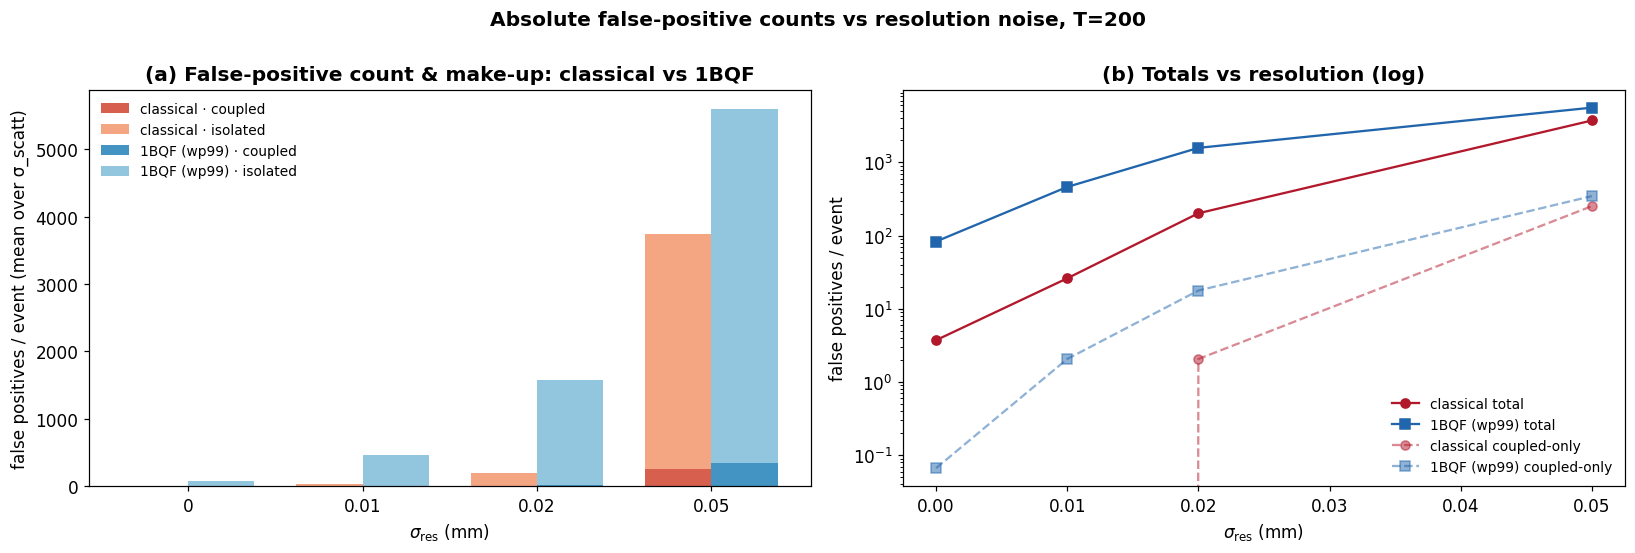

coupled-only FP (dashed) is tiny & solver-independent; the gap to total is isolated leakage


In [5]:
T = 200; sub = agg[agg['n_trk']==T]
# average over sigma_scatt -> FP count vs sigma_res, split isolated/coupled, C vs Q
def fp_counts(solver):
    iso, coup = [], []
    for sr in SR:
        s = sub[sub['sigma_res']==sr]
        per_ss_iso, per_ss_coup = [], []
        for ss in SS:
            ss_s = s[s['sigma_scatt']==ss]
            if ss_s.empty: continue
            i = float(ss_s[ss_s['type']=='isolated'][solver].sum())
            c = float(ss_s[ss_s['type'].isin(['pair','chain>=3','hub'])][solver].sum())
            per_ss_iso.append(i); per_ss_coup.append(c)
        iso.append(np.nanmean(per_ss_iso)); coup.append(np.nanmean(per_ss_coup))
    return np.array(iso), np.array(coup)
isoC, coupC = fp_counts('act_C'); isoQ, coupQ = fp_counts('act_Q_wp')   # 1BQF at wp99

fig, ax = plt.subplots(1, 2, figsize=(15,5))
x = np.arange(len(SR)); w=0.38
ax[0].bar(x-w/2, coupC, w, color='#d6604d', label='classical · coupled')
ax[0].bar(x-w/2, isoC, w, bottom=coupC, color='#f4a582', label='classical · isolated')
ax[0].bar(x+w/2, coupQ, w, color='#4393c3', label='1BQF (wp99) · coupled')
ax[0].bar(x+w/2, isoQ, w, bottom=coupQ, color='#92c5de', label='1BQF (wp99) · isolated')
ax[0].set_xticks(x); ax[0].set_xticklabels([f'{s:g}' for s in SR])
ax[0].set_xlabel(r'$\sigma_{\rm res}$ (mm)'); ax[0].set_ylabel('false positives / event (mean over σ_scatt)')
ax[0].set_title('(a) False-positive count & make-up: classical vs 1BQF', fontweight='bold')
ax[0].legend(frameon=False, fontsize=9)
ax[1].plot(SR, isoC+coupC, 'o-', color='#b2182b', label='classical total')
ax[1].plot(SR, isoQ+coupQ, 's-', color='#2166ac', label='1BQF (wp99) total')
ax[1].plot(SR, coupC, 'o--', color='#b2182b', alpha=.5, label='classical coupled-only')
ax[1].plot(SR, coupQ, 's--', color='#2166ac', alpha=.5, label='1BQF (wp99) coupled-only')
ax[1].set_yscale('log'); ax[1].set_xlabel(r'$\sigma_{\rm res}$ (mm)'); ax[1].set_ylabel('false positives / event')
ax[1].set_title('(b) Totals vs resolution (log)', fontweight='bold'); ax[1].legend(frameon=False, fontsize=9)
fig.suptitle(f'Absolute false-positive counts vs resolution noise, T={T}', fontweight='bold', y=1.0)
fig.tight_layout(); fig.savefig(FIG/'fp_counts_C_vs_Q_T200.png', bbox_inches='tight', facecolor='white')
fig.savefig(FIG/'fp_counts_C_vs_Q_T200.pdf', bbox_inches='tight'); plt.show()
print('coupled-only FP (dashed) is tiny & solver-independent; the gap to total is isolated leakage')

## 4 · Density scaling — cleanest vs noisiest cell

How the census and false-positive composition evolve with track multiplicity $T$
at the extremes of the noise grid.

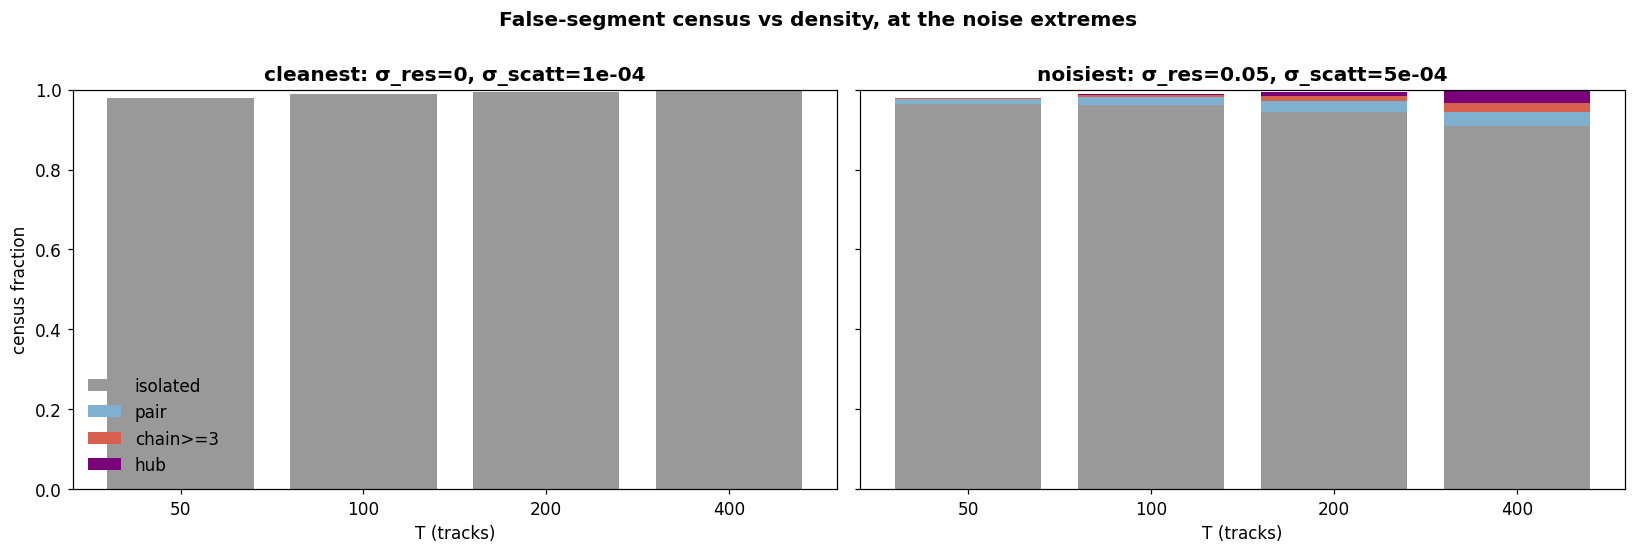

In [6]:
clean = (min(SR), min(SS)); noisy = (max(SR), max(SS))
Ts = sorted(agg['n_trk'].unique())
fig, axes = plt.subplots(1, 2, figsize=(15,5), sharey=True)
for axi,(sr,ss),name in [(axes[0],clean,'cleanest'),(axes[1],noisy,'noisiest')]:
    bottom = np.zeros(len(Ts))
    for t in FALSE_TYPES:
        y = []
        for T in Ts:
            s = agg[(agg['n_trk']==T)&(agg['sigma_res']==sr)&(agg['sigma_scatt']==ss)]
            tot = float(s['count'].sum()) or 1.0
            y.append(float(s[s['type']==t]['count'].sum())/tot)
        axi.bar([str(T) for T in Ts], y, bottom=bottom, color=COL[t], label=t)
        bottom += np.array(y)
    axi.set_title(f'{name}: σ_res={sr:g}, σ_scatt={ss:.0e}', fontweight='bold')
    axi.set_xlabel('T (tracks)'); axi.set_ylim(0,1)
axes[0].set_ylabel('census fraction'); axes[0].legend(frameon=False, loc='lower left')
fig.suptitle('False-segment census vs density, at the noise extremes', fontweight='bold', y=1.0)
fig.tight_layout(); fig.savefig(FIG/'census_vs_T_extremes.png', bbox_inches='tight', facecolor='white')
fig.savefig(FIG/'census_vs_T_extremes.pdf', bbox_inches='tight'); plt.show()

## 5 · Summary table

Per-noise-cell census + false-positive breakdown at T = 200, written to
`outputs/false_positive_types/fp_summary_T200.csv`.

In [7]:
T = 200; sub = agg[agg['n_trk']==T]; rows=[]
for sr in SR:
    for ss in SS:
        s = sub[(sub['sigma_res']==sr)&(sub['sigma_scatt']==ss)]
        cnt = {t: float(s[s['type']==t]['count'].sum()) for t in FALSE_TYPES}
        aC  = {t: float(s[s['type']==t]['act_C'].sum()) for t in FALSE_TYPES}
        aQ  = {t: float(s[s['type']==t]['act_Q_wp'].sum()) for t in FALSE_TYPES}   # 1BQF wp99
        aQf = {t: float(s[s['type']==t]['act_Q'].sum()) for t in FALSE_TYPES}      # fixed-tau record
        tot=sum(cnt.values()) or 1; fpC=sum(aC.values()); fpQ=sum(aQ.values()); fpQf=sum(aQf.values())
        rows.append(dict(sigma_res=sr, sigma_scatt=ss,
            pct_coupled=100*(1-cnt['isolated']/tot),
            fp_C=fpC, fp_C_iso_pct=100*aC['isolated']/fpC if fpC else 0,
            fp_C_hub_pct=100*aC['hub']/fpC if fpC else 0,
            fp_Q_wp=fpQ, fp_Q_wp_iso_pct=100*aQ['isolated']/fpQ if fpQ else 0,
            fp_Q_fixedtau=fpQf))
summ = pd.DataFrame(rows).round(2)
summ.to_csv(HERE/'outputs'/'false_positive_types'/'fp_summary_T200.csv', index=False)
import IPython.display as d; d.display(summ)

,sigma_res,sigma_scatt,pct_coupled,fp_C,fp_C_iso_pct,fp_C_hub_pct,fp_Q_wp,fp_Q_wp_iso_pct,fp_Q_fixedtau
0,0.00,0.0,0.00,0.0,0.00,0.00,6.2,100.00,6.2
1,0.00,0.0,0.04,3.8,100.00,0.00,60.6,100.00,61.0
2,0.00,0.0,0.10,7.4,100.00,0.00,182.8,99.89,183.4
3,0.01,0.0,0.24,22.6,100.00,0.00,403.0,99.75,404.2
4,0.01,0.0,0.28,25.2,100.00,0.00,416.8,99.38,417.2
5,0.01,0.0,0.35,30.6,100.00,0.00,568.6,99.54,569.0
6,0.02,0.0,0.94,157.2,98.98,0.00,1476.6,98.88,1477.6
7,0.02,0.0,0.92,216.0,99.17,0.00,1552.2,99.01,1553.6
8,0.02,0.0,1.00,233.4,98.80,0.00,1717.4,98.75,1718.6
9,0.05,0.0,5.21,3760.8,93.41,1.58,8235.0,93.98,8238.0


## Findings

**1. Resolution noise, not scattering, rewrites the false-segment topology.**
At T = 200 the coupled (pair/chain/hub) false population grows ~1000× from
$\sigma_{\rm res}=0$ (≈7 coupled/event) to $\sigma_{\rm res}=0.05$ mm (≈8 400). Varying
$\sigma_{\rm scatt}$ over $[1,5]\times10^{-4}$ rad barely moves it — wider $\varepsilon$
from resolution smearing is what couples false pairs, consistent with the
$12\arctan^2(\sigma_{\rm res}/\Delta z)$ vs $2\sigma_{\rm scatt}^2$ weighting in the
$\varepsilon$ formula.

**2. The dominant false positive is *isolated leakage*, not coupled confusion.**
In clean Run-3 events 100 % of false positives are coupled (hub/chain). Here, once
$\sigma_{\rm res}\gtrsim0.02$ mm, **94–99 %** of both solvers' false positives are
*isolated* segments — uncoupled triplets that should rest at the $0.25$ attractor but
are pushed over $\tau$ by the corrupted high-occupancy solve. The genuinely-coupled
false positives stay a small, almost noise-independent floor (dashed lines, §3b).

**3. The 1BQF is not more pure than the classical solver here — it is less
(quoted at its wp99 headline working point).**
At low/moderate noise the 1BQF fires **more** false positives than classical
(σ_res=0: ~7→~183/event; σ_res=0.01: ~26→~460), almost all isolated. Notably the
count is **essentially identical at wp99 and at the fixed-τ=0.35 record** (183 vs
183): the leaked isolated amplitudes sit far above *both* cuts, so this purity
deficit is threshold-robust — a genuine flood of isolated leakage after the
$\|s_Q\|=\|s_C\|$ rescale, not a cut artefact. (The 1BQF *efficiency* story is the
opposite: the fixed-τ ~75 % plateau **was** the cut artefact; wp99 recovers
~100 %.) *(A few T=200 σ_res=0.05 quantum points are missing — expensive CPU
statevector jobs; the GPU re-run will fill them.)*

These plug directly into the Epsilon_study_2 report: §4.8 purity collapse is
resolution-driven, and the leakage is topological (isolated), which motivates an
absolute small-score veto for the quantum readout rather than the τ×max rule.